### Integrantes del grupo

Aleicer Vesga Rueda

Jaider Morales Bautista

### Crecion del Catalogo, Shchema y Tablas

In [0]:
%sql
--Creamos el catálogo y el esquema
CREATE CATALOG IF NOT EXISTS salud_digital;
CREATE SCHEMA IF NOT EXISTS salud_digital.vital_sign;

--Se usa el esquema
USE salud_digital.vital_sign;

In [0]:
%sql
DESCRIBE TABLE salud_digital.vital_sign.unified_measurements_table

col_name,data_type,comment
patient_id,int,null
heart_rate,int,null
respiratory_rate,int,null
timestamp,timestamp,null
body_temperature,double,null
oxygen_saturation,double,null
systolic_blood_pressure,int,null
diastolic_blood_pressure,int,null
age,int,null
gender,string,null


### Transformaciones de fecha

In [0]:
%sql
SELECT 
    timestamp AS Fecha_Dato_Original, 
    to_date(timestamp) AS Fecha_Transformada
FROM salud_digital.vital_sign.unified_measurements_table
LIMIT 20;

Fecha_Dato_Original,Fecha_Transformada
2024-07-19T21:53:45.729Z,2024-07-19
2024-07-19T21:52:45.729Z,2024-07-19
2024-07-19T21:51:45.729Z,2024-07-19
2024-07-19T21:50:45.729Z,2024-07-19
2024-07-19T21:49:45.729Z,2024-07-19
2024-07-19T21:48:45.729Z,2024-07-19
2024-07-19T21:47:45.729Z,2024-07-19
2024-07-19T21:46:45.729Z,2024-07-19
2024-07-19T21:45:45.729Z,2024-07-19
2024-07-19T21:44:45.729Z,2024-07-19


In [0]:
%sql
-- Validación si hay fechas que fallaron en la conversión (quedarían NULL)
SELECT *
FROM salud_digital.vital_sign.unified_measurements_table
WHERE timestamp IS NOT NULL 
  AND to_date(timestamp) IS NULL;

patient_id,heart_rate,respiratory_rate,timestamp,body_temperature,oxygen_saturation,systolic_blood_pressure,diastolic_blood_pressure,age,gender,weight_kg,height_m,derived_hrv,derived_pulse_pressure,derived_bmi,derived_map,risk_category


Columnas apartir de la fecha

In [0]:
%sql
SELECT 
    to_date(timestamp) AS Fecha_Transformada,
    year(to_date(timestamp)) AS Anio,
    month(to_date(timestamp)) AS Mes,
    day(to_date(timestamp)) AS Dia,
    (weekday(to_date(timestamp)) + 1) AS Dia_Semana,
    CASE weekday(to_date(timestamp))
        WHEN 0 THEN 'Lunes'
        WHEN 1 THEN 'Martes'
        WHEN 2 THEN 'Miércoles'
        WHEN 3 THEN 'Jueves'
        WHEN 4 THEN 'Viernes'
        WHEN 5 THEN 'Sábado'
        WHEN 6 THEN 'Domingo'
    END AS Nombre_Dia
FROM salud_digital.vital_sign.unified_measurements_table
LIMIT 20;

Fecha_Transformada,Anio,Mes,Dia,Dia_Semana,Nombre_Dia
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes
2024-07-19,2024,7,19,5,Viernes


### Resumen mensual

In [0]:
%sql
CREATE OR REPLACE TABLE salud_digital.vital_sign.resumen_mensual AS
SELECT
    year(to_date(timestamp)) AS anio,
    month(to_date(timestamp)) AS mes,
    COUNT(*) AS total_mediciones,
    COUNT(DISTINCT patient_id) AS pacientes_unicos,
    AVG(heart_rate) AS prom_frecuencia_cardiaca,
    AVG(body_temperature) AS prom_temperatura,
    AVG(oxygen_saturation) AS prom_saturacion
FROM salud_digital.vital_sign.unified_measurements_table
WHERE timestamp IS NOT NULL
GROUP BY
    year(to_date(timestamp)),
    month(to_date(timestamp))
ORDER BY anio DESC, mes DESC;

-- Ver los primeros resultados
SELECT *
FROM salud_digital.vital_sign.resumen_mensual
LIMIT 10;

anio,mes,total_mediciones,pacientes_unicos,prom_frecuencia_cardiaca,prom_temperatura,prom_saturacion
2024,7,27234,27234,79.53572739957406,36.74649784918014,97.50891348840457
2024,6,43200,43200,79.58229166666666,36.74650535216638,97.51165679575413
2024,5,44640,44640,79.60152329749104,36.747582445913245,97.49592917586408
2024,4,43200,43200,79.46377314814815,36.74936507743913,97.49821843757111
2024,3,41746,41746,79.48215397882431,36.75125145106023,97.50926877829777



### Limpieza, antes y después

### Evidencia — Antes de limpiar

In [0]:
%sql
SELECT
    gender,
    body_temperature,
    heart_rate,
    age,
    oxygen_saturation,
    timestamp
FROM salud_digital.vital_sign.unified_measurements_table
LIMIT 10;

gender,body_temperature,heart_rate,age,oxygen_saturation,timestamp
Female,36.861707108012936,60,37,95.70204560529264,2024-07-19T21:53:45.729Z
Male,36.51163284237428,63,77,96.68941321884793,2024-07-19T21:52:45.729Z
Female,37.05204858016934,63,68,98.50826478317362,2024-07-19T21:51:45.729Z
Female,36.654747504854214,99,41,95.01180149205474,2024-07-19T21:50:45.729Z
Female,36.97509754422735,69,25,98.6237917407539,2024-07-19T21:49:45.729Z
Male,36.884979062580214,79,22,95.9871292033958,2024-07-19T21:48:45.729Z
Male,37.273639584377314,81,43,99.45671576538214,2024-07-19T21:47:45.729Z
Female,36.85263343367673,96,72,97.1241246758814,2024-07-19T21:46:45.729Z
Male,36.044191421051224,83,50,98.58449733479578,2024-07-19T21:45:45.729Z
Male,36.95717841280944,66,61,97.91626727887889,2024-07-19T21:44:45.729Z


### Transformación y creación de nueva tabla limpia

In [0]:
%sql
CREATE OR REPLACE TABLE salud_digital.vital_sign.vital_sign_limpia AS
SELECT
    -- Normalización: quitar espacios y minúsculas
    trim(lower(gender)) AS gender_limpio,
    
    -- Temperatura: corregir valores anómalos y redondear a 1 decimal
    round(
        CASE
            WHEN body_temperature IS NULL THEN 36.5
            WHEN body_temperature < 30 OR body_temperature > 45 THEN 36.5
            ELSE body_temperature
        END
    , 1) AS temperatura_limpia,

    -- Frecuencia cardiaca: rangos clínicos válidos + redondeo
    round(
        CASE
            WHEN heart_rate IS NULL THEN 75
            WHEN heart_rate < 30 OR heart_rate > 220 THEN 75
            ELSE heart_rate
        END
    , 0) AS frecuencia_cardiaca_limpia,

    -- Edad: dejamos solo 0–110, lo demás a NULL
    CASE
        WHEN age < 0 OR age > 110 THEN NULL
        ELSE age
    END AS edad_limpia,

    -- Saturación de oxígeno: valores razonables 70–100, imputamos 95
    round(
        CASE
            WHEN oxygen_saturation IS NULL THEN 95
            WHEN oxygen_saturation < 70 OR oxygen_saturation > 100 THEN 95
            ELSE oxygen_saturation
        END
    , 0) AS spo2_limpia,

    -- Mantener columnas originales para poder comparar
    *
FROM salud_digital.vital_sign.unified_measurements_table;

num_affected_rows,num_inserted_rows


### Datos limpios

In [0]:
%sql
SELECT
    gender_limpio,
    temperatura_limpia,
    frecuencia_cardiaca_limpia,
    edad_limpia,
    spo2_limpia
FROM salud_digital.vital_sign.vital_sign_limpia
LIMIT 10;

gender_limpio,temperatura_limpia,frecuencia_cardiaca_limpia,edad_limpia,spo2_limpia
female,36.9,60,37,96.0
male,36.5,63,77,97.0
female,37.1,63,68,99.0
female,36.7,99,41,95.0
female,37.0,69,25,99.0
male,36.9,79,22,96.0
male,37.3,81,43,99.0
female,36.9,96,72,97.0
male,36.0,83,50,99.0
male,37.0,66,61,98.0


In [0]:
%sql
DESCRIBE TABLE salud_digital.vital_sign.vital_sign_limpia;

col_name,data_type,comment
gender_limpio,string,null
temperatura_limpia,double,null
frecuencia_cardiaca_limpia,int,null
edad_limpia,int,null
spo2_limpia,double,null
patient_id,int,null
heart_rate,int,null
respiratory_rate,int,null
timestamp,timestamp,null
body_temperature,double,null


### Visualizaciones con librerías

In [0]:
%sql
SELECT 
    gender_limpio AS genero,
    COUNT(*) AS total_mediciones
FROM salud_digital.vital_sign.vital_sign_limpia
GROUP BY gender_limpio
ORDER BY total_mediciones DESC;

genero,total_mediciones
female,100117
male,99903


**Lenguaje de trabajo (Equivalente en pyspark)**

In [0]:
df_genero = (
    df_limpio
    .groupBy("gender_limpio")
    .count()
    .withColumnRenamed("count", "total_mediciones")
    .orderBy(F.desc("total_mediciones"))
)

display(df_genero)

gender_limpio,total_mediciones
female,100117
male,99903


In [0]:
%sql
SELECT
    year(timestamp) AS anio,
    month(timestamp) AS mes,
    AVG(temperatura_limpia) AS temp_promedio
FROM salud_digital.vital_sign.vital_sign_limpia
GROUP BY anio, mes
ORDER BY anio, mes;

anio,mes,temp_promedio
2024,3,36.75110429741801
2024,4,36.749361111110865
2024,5,36.7473499103942
2024,6,36.74652546296311
2024,7,36.74653007270326


**Lenguaje de trabajo (Equivalente en pyspark)**

In [0]:
df_temp_mes = (
    df_limpio
    .withColumn("anio", F.year("timestamp"))
    .withColumn("mes", F.month("timestamp"))
    .groupBy("anio", "mes")
    .agg(F.avg("temperatura_limpia").alias("temp_promedio"))
    .orderBy("anio", "mes")
)

display(df_temp_mes)

anio,mes,temp_promedio
2024,3,36.75110429741801
2024,4,36.749361111110865
2024,5,36.7473499103942
2024,6,36.74652546296311
2024,7,36.74653007270326


In [0]:
%sql
SELECT
    CASE weekday(timestamp)
        WHEN 0 THEN 'Lunes'
        WHEN 1 THEN 'Martes'
        WHEN 2 THEN 'Miércoles'
        WHEN 3 THEN 'Jueves'
        WHEN 4 THEN 'Viernes'
        WHEN 5 THEN 'Sábado'
        WHEN 6 THEN 'Domingo'
    END AS dia_semana,
    COUNT(*) AS total_mediciones
FROM salud_digital.vital_sign.vital_sign_limpia
GROUP BY weekday(timestamp)
ORDER BY total_mediciones DESC;

dia_semana,total_mediciones
Lunes,28800
Miércoles,28800
Jueves,28800
Martes,28800
Domingo,28786
Viernes,28674
Sábado,27360


**Lenguaje de trabajo (Equivalente en pyspark)**

In [0]:
from pyspark.sql import functions as F

df_limpio = spark.table("salud_digital.vital_sign.vital_sign_limpia")

df_dia_semana = (
    df_limpio
    .withColumn("weekday_num", F.weekday("timestamp"))  # 0=Lunes,...6=Domingo
    .withColumn(
        "dia_semana",
        F.when(F.col("weekday_num") == 0, "Lunes")
         .when(F.col("weekday_num") == 1, "Martes")
         .when(F.col("weekday_num") == 2, "Miércoles")
         .when(F.col("weekday_num") == 3, "Jueves")
         .when(F.col("weekday_num") == 4, "Viernes")
         .when(F.col("weekday_num") == 5, "Sábado")
         .otherwise("Domingo")
    )
    .groupBy("dia_semana")
    .agg(F.count("*").alias("total_mediciones"))
    .orderBy(F.desc("total_mediciones"))
)

display(df_dia_semana)

dia_semana,total_mediciones
Lunes,28800
Miércoles,28800
Jueves,28800
Martes,28800
Domingo,28786
Viernes,28674
Sábado,27360


### Visualizaciones en python con librerias

In [0]:
from pyspark.sql import functions as F

df_limpio = spark.table("salud_digital.vital_sign.vital_sign_limpia")

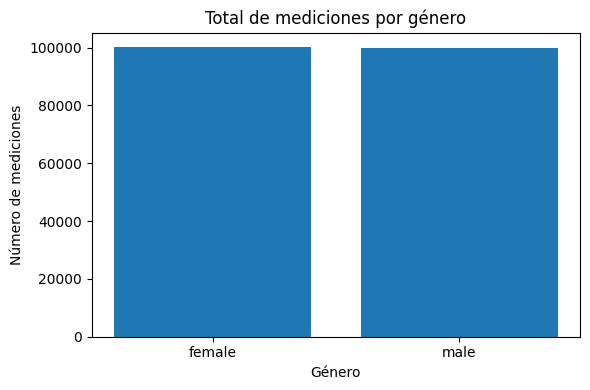

In [0]:
import matplotlib.pyplot as plt

# Agregación por género en Spark
df_genero = (
    df_limpio
    .groupBy("gender_limpio")
    .count()
    .withColumnRenamed("count", "total_mediciones")
)

pdf_genero = df_genero.toPandas().sort_values("total_mediciones", ascending=False)

plt.figure(figsize=(6,4))
plt.bar(pdf_genero["gender_limpio"], pdf_genero["total_mediciones"])
plt.title("Total de mediciones por género")
plt.xlabel("Género")
plt.ylabel("Número de mediciones")
plt.tight_layout()
plt.show()

Se observa una distribución muy equilibrada entre ambos géneros: 50.05% femenino y 49.95% masculino.
Esto indica que el dataset no presenta sesgo de género significativo en la captura de mediciones.
Esta representación balanceada mejora la confiabilidad de futuros análisis poblacionales.

In [0]:
import plotly.express as px

df_temp = (
    df_limpio
    .withColumn("anio", F.year("timestamp"))
    .withColumn("mes", F.month("timestamp"))
    .groupBy("anio", "mes")
    .agg(F.avg("temperatura_limpia").alias("temp_promedio"))
)

pdf_temp = df_temp.toPandas().sort_values(["anio", "mes"])

# Crear una columna año-mes tipo string para el eje X
pdf_temp["anio_mes"] = pdf_temp["anio"].astype(str) + "-" + pdf_temp["mes"].astype(str).str.zfill(2)

fig = px.line(
    pdf_temp,
    x="anio_mes",
    y="temp_promedio",
    color="anio",
    markers=True,
    title="Temperatura promedio por año y mes"
)
fig.update_layout(xaxis_title="Año-Mes", yaxis_title="Temperatura promedio (°C)")
fig.show()

La temperatura corporal promedio presenta una ligera tendencia a la baja entre marzo y julio de 2024, con variaciones mínimas (≈0.005 °C).
Las diferencias son muy pequeñas, lo que sugiere que no hay cambios clínicos relevantes en la temperatura promedio mensual.
La estabilidad de la temperatura indica un control fisiológico normal en la población monitoreada.

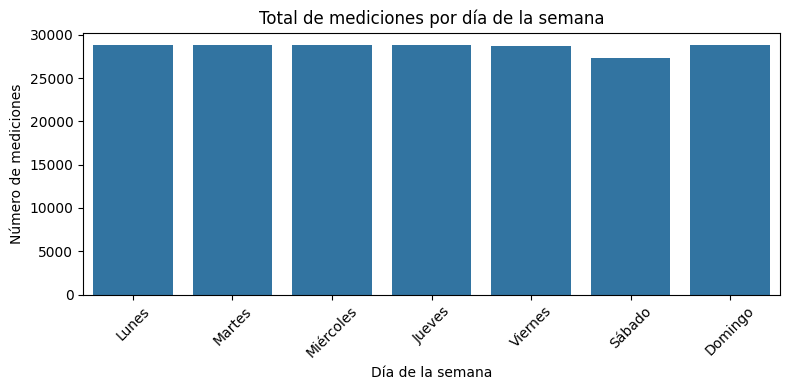

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Agregación por día de la semana
df_dia = (
    df_limpio
    .withColumn("weekday_num", F.weekday("timestamp"))  # 0=Lunes,...6=Domingo
    .withColumn(
        "dia_semana",
        F.when(F.col("weekday_num") == 0, "Lunes")
         .when(F.col("weekday_num") == 1, "Martes")
         .when(F.col("weekday_num") == 2, "Miércoles")
         .when(F.col("weekday_num") == 3, "Jueves")
         .when(F.col("weekday_num") == 4, "Viernes")
         .when(F.col("weekday_num") == 5, "Sábado")
         .otherwise("Domingo")
    )
    .groupBy("weekday_num", "dia_semana")
    .count()
    .withColumnRenamed("count", "total_mediciones")
)

pdf_dia = df_dia.toPandas()

# Orden lógico de los días
orden_dias = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
pdf_dia["dia_semana"] = pd.Categorical(pdf_dia["dia_semana"], categories=orden_dias, ordered=True)
pdf_dia = pdf_dia.sort_values("dia_semana")

plt.figure(figsize=(8,4))
sns.barplot(data=pdf_dia, x="dia_semana", y="total_mediciones")
plt.title("Total de mediciones por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Número de mediciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Lunes, martes, miércoles y jueves concentran ligeramente más mediciones que los demás días.
Esto sugiere mayor actividad de monitoreo durante días laborales y una leve reducción durante fines de semana.
La variación es baja, por lo que la disponibilidad de mediciones se mantiene relativamente uniforme durante toda la semana.

Lenguaje de trabajo  SQL y Spark